# 05 — QV: Value of Agricultural Production

QV adds the **economic** dimension: which crops/countries generate the most value,
and how value-per-tonne (a rough price/quality proxy) shifts. Pairing QV with QCL
lets you separate "grows a lot of cheap calories" from "grows high-value crops."

Questions:
- Does production volume (QCL) track economic value (QV), or are they decoupled?
- Which crops are rising in value share? (economic-shift hypothesis)

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import pandas as pd
import matplotlib.pyplot as plt

from src.load import load_dataset, load_codes
from src.clean import standardize_columns, split_aggregates, resolve_china, data_quality_report
from src.viz import trend_over_time, save

## 1. Load QV and inspect elements — prefer constant-price (int'l $) for cross-time comparison

In [2]:
qv_full = standardize_columns(load_dataset("QV"))
print(qv_full[["element_code", "element", "unit"]].drop_duplicates().to_string(index=False))

[cache] QV_long.parquet
 element_code                                                  element      unit
          152  Gross Production Value (constant 2014-2016 thousand I$) 1000 Int$
           55 Gross Production Value (constant 2014-2016 thousand SLC)  1000 SLC
           58 Gross Production Value (constant 2014-2016 thousand US$)  1000 USD
           56            Gross Production Value (current thousand SLC)  1000 SLC
           57            Gross Production Value (current thousand US$)  1000 USD


## 2. Filter to the same staples as notebook 03, using a constant-price element
Pick a "Gross Production Value (constant ... I$)" element from the list above.

In [3]:
STAPLES = ["Wheat", "Rice", "Maize (corn)"]   # match notebook 03 spelling
VALUE_ELEMENT = "Gross Production Value (constant 2014-2016 thousand I$)"  # adjust to what's listed

qv = qv_full[qv_full["item"].isin(STAPLES)]
qv = qv[qv["element"] == VALUE_ELEMENT].copy() if VALUE_ELEMENT in qv["element"].unique() else qv
print("elements kept:", qv["element"].unique().tolist())
qv.head()

elements kept: ['Gross Production Value (constant 2014-2016 thousand I$)']


,area_code,area_code_(m49),area,item_code,item_code_(cpc),item,element_code,element,unit,year,value,flag
18,2,'004,Afghanistan,56,'0112,Maize (corn),152,Gross Production Value (constant 2014-2016 tho...,1000 Int$,1961,140512.0,E
70,2,'004,Afghanistan,27,'0113,Rice,152,Gross Production Value (constant 2014-2016 tho...,1000 Int$,1961,124751.0,E
87,2,'004,Afghanistan,15,'0111,Wheat,152,Gross Production Value (constant 2014-2016 tho...,1000 Int$,1961,539737.0,E
138,3,'008,Albania,56,'0112,Maize (corn),152,Gross Production Value (constant 2014-2016 tho...,1000 Int$,1961,30934.0,E
217,3,'008,Albania,27,'0113,Rice,152,Gross Production Value (constant 2014-2016 tho...,1000 Int$,1961,1800.0,E


## 3. Quality

In [4]:
for k, v in data_quality_report(qv).items():
    print(f"{k}: {v}")

rows: 29480
n_missing_value: 0
pct_missing_value: 0.0
flag_distribution: {'E': 1.0}
year_min: 1961
year_max: 2024


In [5]:
countries, aggregates = split_aggregates(qv)
countries = resolve_china(countries)

## 4. Global value trend by crop

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/qv_value_by_crop.png


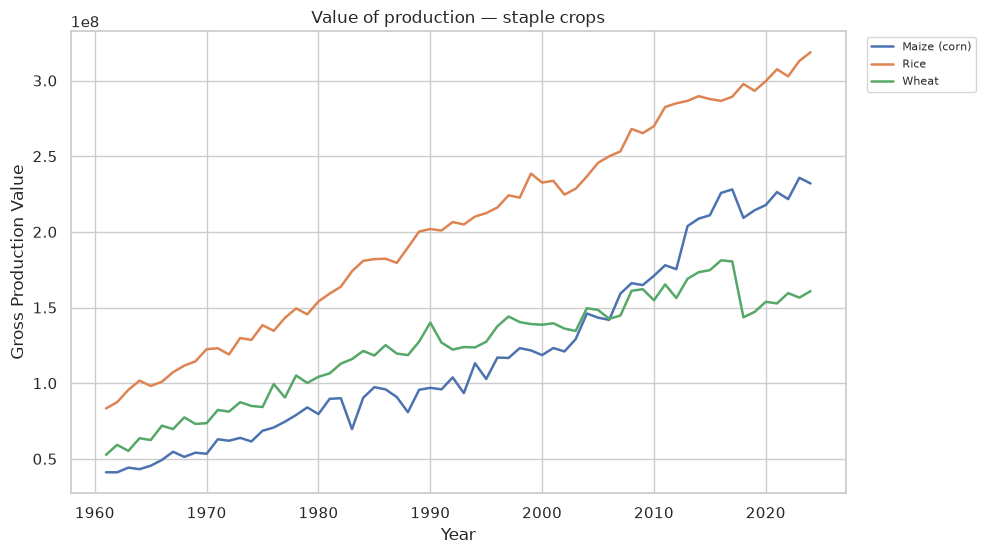

In [6]:
fig, ax = trend_over_time(countries, "year", "value", group_col="item",
                          title="Value of production — staple crops",
                          ylabel="Gross Production Value")
save(fig, "qv_value_by_crop")
plt.show()

## 5. Value vs Volume — are they decoupling?
Join QV value with QCL production and look at value-per-tonne over time.
Requires the QCL staples_full cache from notebook 03.

[cache] QCL_long.parquet
figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/qv_value_per_tonne.png


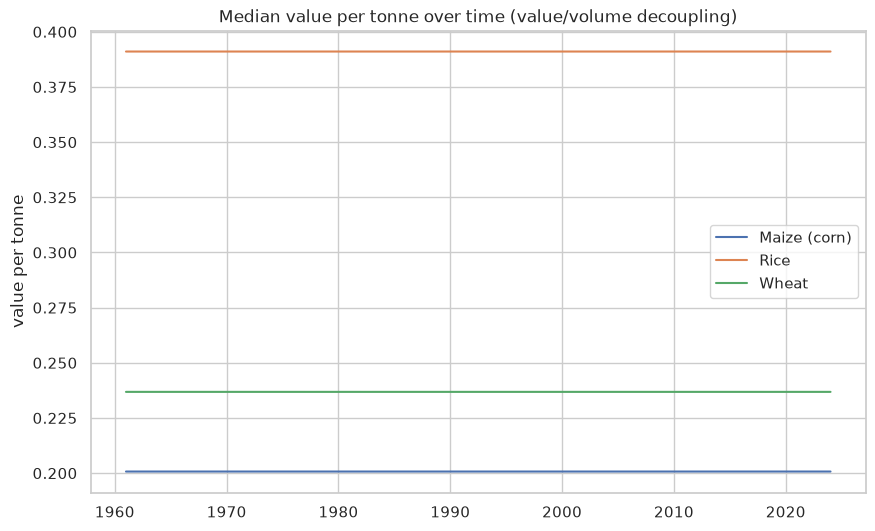

In [7]:
qcl = standardize_columns(load_dataset("QCL"))
qcl = qcl[qcl["item"].isin(STAPLES)]
qcl_prod = qcl[qcl["element"].str.contains("Production", na=False)]

merged = (
    countries.groupby(["area", "item", "year"])["value"].sum().rename("value_usd").reset_index()
    .merge(
        qcl_prod.groupby(["area", "item", "year"])["value"].sum().rename("prod_t").reset_index(),
        on=["area", "item", "year"], how="inner",
    )
)
merged["value_per_tonne"] = merged["value_usd"] / merged["prod_t"].replace(0, pd.NA)

world = merged.groupby(["item", "year"])["value_per_tonne"].median().reset_index()
fig, ax = plt.subplots(figsize=(10, 6))
for item, g in world.groupby("item"):
    ax.plot(g["year"], g["value_per_tonne"], label=item)
ax.set_title("Median value per tonne over time (value/volume decoupling)")
ax.set_ylabel("value per tonne")
ax.legend()
save(fig, "qv_value_per_tonne")
plt.show()

**Checkpoint:** QV is the differentiator — most datathon teams stop at volume.
An economic angle (value shifting faster than volume) is a strong, less-obvious hypothesis.